# LSTM-Based Time-Series Forecasting

## Weather Temperature Forecasting using Jena Climate Dataset

### Deep Learning Assignment

**Objective:**  
To develop a Long Short-Term Memory (LSTM) based deep learning model
for time-series forecasting using historical weather observations.

### Dataset
Jena Climate 2009–2016 Dataset

### Target Variable
Temperature (`T (degC)`)

### Model
Long Short-Term Memory (LSTM)

### Workflow

1. Load and understand the dataset
2. Perform exploratory data analysis
3. Preprocess the date-time information
4. Select the target variable
5. Reduce the dataset frequency for efficient training
6. Split the data chronologically
7. Normalize the data
8. Create sequential input samples
9. Build the LSTM model
10. Train the model
11. Evaluate forecasting performance
12. Visualize actual vs predicted temperature
13. Forecast future temperature values

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization,
data preprocessing, evaluation, and development of the LSTM model.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reproducibility
np.random.seed(42)

## 2. Load the Dataset

The Jena Climate dataset contains weather measurements recorded at
10-minute intervals between 2009 and 2016.

Since the original dataset contains more than 420,000 observations,
the data will later be resampled to hourly frequency to make model
training computationally efficient while preserving the overall
temperature trend.

In [2]:
# Load the dataset
df = pd.read_csv("jena_climate_2009_2016.csv")

# Display the first five records
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Dataset Overview

We inspect the dimensions, columns, data types, and statistical
properties of the dataset before performing preprocessing.

In [3]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (420551, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Data Types:
Date Time           object
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object


In [4]:
# Statistical summary
df.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [5]:
# Check for missing values
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


## 4. Convert Date-Time Information

The `Date Time` column contains both date and time information.

It is converted into Pandas datetime format and used as the index.
This allows us to perform time-based operations such as resampling.

In [6]:
# Convert Date Time column to datetime format
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

# Set Date Time as index
df.set_index("Date Time", inplace=True)

# Sort the dataset chronologically
df.sort_index(inplace=True)

# Display the first records
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [7]:
# Select temperature as the target variable
temperature = df["T (degC)"].copy()

# Display basic information
print("Target Variable: T (degC)")
print("Number of observations:", len(temperature))

temperature.head()

Target Variable: T (degC)
Number of observations: 420551


Date Time
2009-01-01 00:10:00   -8.02
2009-01-01 00:20:00   -8.41
2009-01-01 00:30:00   -8.51
2009-01-01 00:40:00   -8.31
2009-01-01 00:50:00   -8.27
Name: T (degC), dtype: float64

## 6. Visualize the Original Temperature Series

The following plot shows temperature measurements recorded over the
complete period.

Because the dataset contains several years of observations, the plot
helps us understand the long-term seasonal behavior of temperature.

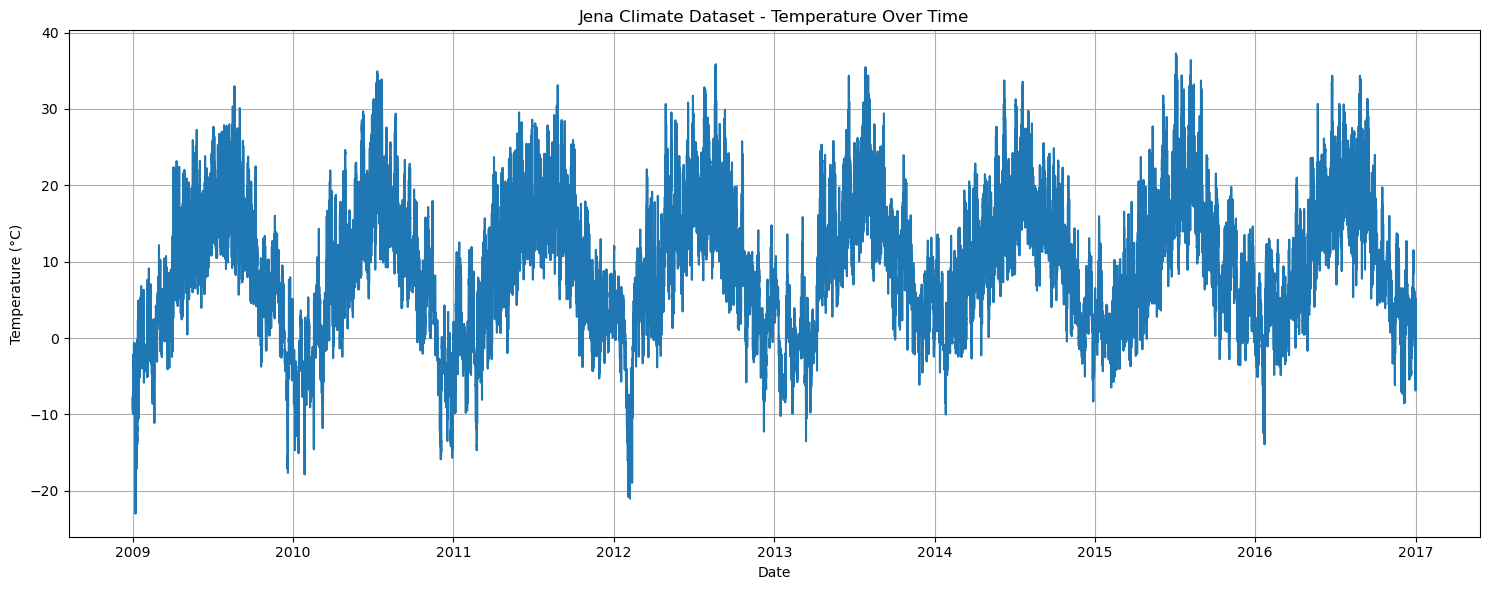

In [8]:
plt.figure(figsize=(15, 6))

plt.plot(
    temperature.index,
    temperature.values
)

plt.title("Jena Climate Dataset - Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Resample the Data to Hourly Frequency

The original dataset contains measurements every 10 minutes.

This produces a very large number of training samples. To make the
LSTM training more efficient, the observations are resampled to
hourly frequency.

The mean temperature of each hour is used as the hourly observation.

This also reduces short-term noise while preserving the important
temporal and seasonal patterns.

In [9]:
# Resample temperature to hourly frequency
hourly_temperature = temperature.resample("1h").mean()

# Remove any missing observations
hourly_temperature = hourly_temperature.dropna()

print("Original observations:", len(temperature))
print("Hourly observations:", len(hourly_temperature))

hourly_temperature.head()

Original observations: 420551
Hourly observations: 70041


Date Time
2009-01-01 00:00:00   -8.304000
2009-01-01 01:00:00   -8.065000
2009-01-01 02:00:00   -8.763333
2009-01-01 03:00:00   -8.896667
2009-01-01 04:00:00   -9.348333
Name: T (degC), dtype: float64

## 8. Visualize Hourly Temperature

The resampled series provides a cleaner representation of the
temperature variation and is more suitable for LSTM training.

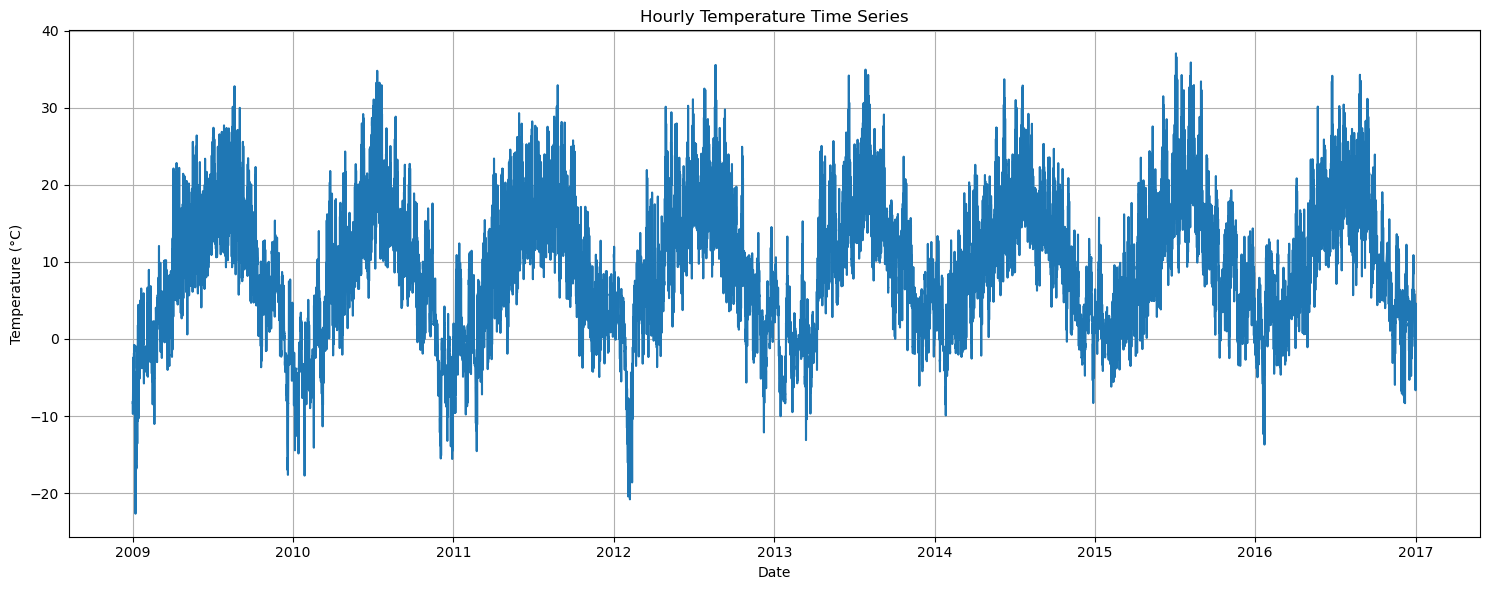

In [10]:
plt.figure(figsize=(15, 6))

plt.plot(
    hourly_temperature.index,
    hourly_temperature.values
)

plt.title("Hourly Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 9. Train-Test Split

For time-series forecasting, random train-test splitting should be
avoided because it can cause future information to enter the training
data.

Therefore, the dataset is divided chronologically:

- 80% → Training data
- 20% → Testing data

The model learns from the past and is evaluated on later observations.

In [11]:
# Convert series to NumPy array
data = hourly_temperature.values.reshape(-1, 1)

# Calculate training size
train_size = int(len(data) * 0.80)

# Chronological split
train_data = data[:train_size]
test_data = data[train_size:]

print("Total observations :", len(data))
print("Training observations:", len(train_data))
print("Testing observations :", len(test_data))

Total observations : 70041
Training observations: 56032
Testing observations : 14009


## 10. Normalize the Data

LSTM models generally train more effectively when input values are
scaled to a smaller numerical range.

Min-Max Scaling transforms the temperature values into the range
[0, 1].

The scaler is fitted only on the training data to prevent data leakage.

In [12]:
# Initialize Min-Max scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform training data
train_scaled = scaler.fit_transform(train_data)

# Transform test data using the same scaler
test_scaled = scaler.transform(test_data)

print("Scaled training range:")
print(train_scaled.min(), "to", train_scaled.max())

Scaled training range:
0.0 to 1.0


## 11. Create Sequential Data for LSTM

LSTM networks require sequential input.

A sliding-window approach is used to convert the time series into
input-output pairs.

For this experiment, the previous **24 hourly observations** are used
to predict the next hour's temperature.

Therefore:

**24 previous hours → next hour temperature**

This allows the LSTM to learn short-term temporal dependencies.

In [13]:
# Number of previous time steps used for prediction
SEQUENCE_LENGTH = 24


def create_sequences(data, sequence_length):
    """
    Create input-output sequences for LSTM forecasting.

    Parameters
    ----------
    data : numpy.ndarray
        Scaled time-series data.

    sequence_length : int
        Number of previous observations used as input.

    Returns
    -------
    X : numpy.ndarray
        Input sequences.

    y : numpy.ndarray
        Target values.
    """

    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [14]:
# Create training sequences
X_train, y_train = create_sequences(
    train_scaled,
    SEQUENCE_LENGTH
)

# Create testing sequences
X_test, y_test = create_sequences(
    test_scaled,
    SEQUENCE_LENGTH
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (56008, 24, 1)
y_train shape: (56008, 1)
X_test shape: (13985, 24, 1)
y_test shape: (13985, 1)


## 12. Understand the LSTM Input Structure

The input to an LSTM has three dimensions:

    (Samples, Time Steps, Features)

For this experiment:

- **Samples:** Number of training sequences
- **Time Steps:** 24 hours
- **Features:** 1 temperature measurement

Therefore, each training sample represents 24 consecutive hourly
temperature observations.

## 13. Build the LSTM Model

The model consists of two LSTM layers.

### Architecture

- LSTM layer → 64 units
- Dropout → 20%
- LSTM layer → 32 units
- Dropout → 20%
- Dense output layer → 1 neuron

The final Dense layer produces the predicted temperature for the
next time step.

In [15]:
# Create Sequential LSTM model
model = Sequential()

# First LSTM layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Dropout regularization
model.add(Dropout(0.2))

# Second LSTM layer
model.add(
    LSTM(
        units=32,
        return_sequences=False
    )
)

# Dropout regularization
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))

# Display model architecture
model.summary()

c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 14. Compile the Model

The Adam optimizer is used for optimization and Mean Squared Error
(MSE) is used as the loss function.

MSE is suitable for this regression-based forecasting problem because
it penalizes larger prediction errors more strongly.

In [16]:
# Compile the LSTM model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

print("Model compiled successfully.")

Model compiled successfully.


## 15. Train the LSTM Model

The model is trained using the training sequences.

A validation split of 10% is used to monitor the model's performance
on unseen training samples during training.

In [17]:
# Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0067 - val_loss: 8.4021e-04
Epoch 2/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0026 - val_loss: 6.2938e-04
Epoch 3/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0016 - val_loss: 4.4142e-04
Epoch 4/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0010 - val_loss: 3.0174e-04
Epoch 5/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 6.6687e-04 - val_loss: 2.3210e-04
Epoch 6/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5.0638e-04 - val_loss: 1.6972e-04
Epoch 7/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 4.3518e-04 - val_loss: 1.9771e-04
Epoch 8/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 4.0773e-04 - val_loss: 1.2315e-04
Epoch 9/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 3.8550e-04 - val_loss: 1.3998e-04
Epoch 10/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 3.7349e-04 - val_loss: 1.1942e-04
Epoch 11/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step 

## 16. Plot Training and Validation Loss

Training and validation loss are plotted to understand how the model
learned over successive epochs.

A decreasing training loss indicates that the model is learning the
patterns present in the training data.

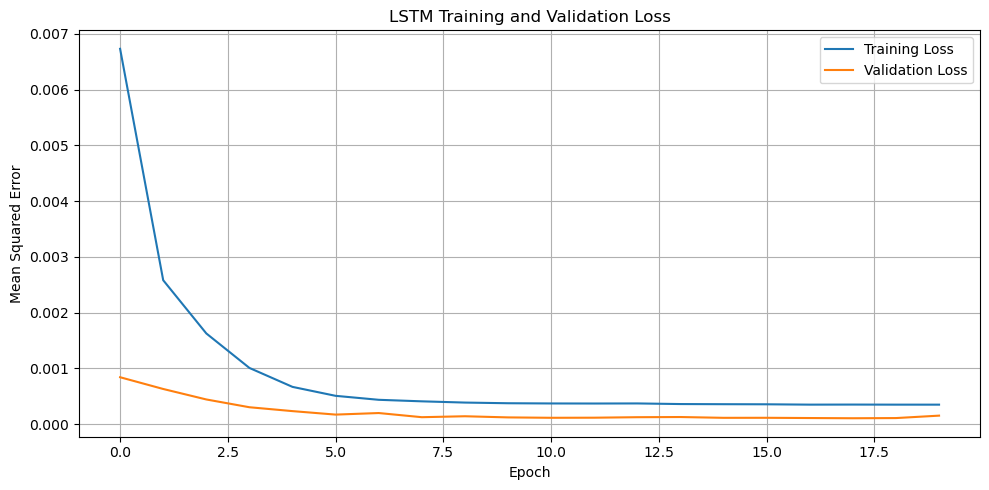

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 17. Generate Predictions

The trained LSTM model is now used to predict temperature values
for the test dataset.

The predictions are initially produced in the normalized [0, 1]
scale and are then converted back to degrees Celsius.

In [19]:
# Generate predictions
predictions_scaled = model.predict(
    X_test,
    verbose=1
)

# Convert predictions back to original temperature scale
predictions = scaler.inverse_transform(
    predictions_scaled
)

# Convert actual values back to original scale
actual = scaler.inverse_transform(
    y_test
)

print("Predictions generated successfully.")

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predictions generated successfully.


## 18. Evaluate the Model

Three evaluation metrics are used:

### MAE — Mean Absolute Error
Represents the average absolute difference between actual and
predicted temperature.

### RMSE — Root Mean Squared Error
Measures the square root of the average squared prediction error.

### R² Score
Indicates how well the model explains the variation in the actual
temperature values.

For MAE and RMSE, lower values indicate better performance.
For R², a value closer to 1 indicates better performance.

In [20]:
# Calculate evaluation metrics
mae = mean_absolute_error(
    actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

r2 = r2_score(
    actual,
    predictions
)

# Display results
print("=" * 40)
print("       LSTM MODEL PERFORMANCE")
print("=" * 40)

print(f"Mean Absolute Error (MAE)  : {mae:.4f} °C")
print(f"Root Mean Squared Error    : {rmse:.4f} °C")
print(f"R² Score                   : {r2:.4f}")

print("=" * 40)

       LSTM MODEL PERFORMANCE
Mean Absolute Error (MAE)  : 0.5265 °C
Root Mean Squared Error    : 0.6974 °C
R² Score                   : 0.9926


## 19. Actual vs Predicted Temperature

The following graph compares the actual temperature values with
the temperature predicted by the LSTM model.

A good forecasting model should follow the overall trend and
short-term fluctuations of the actual temperature series.

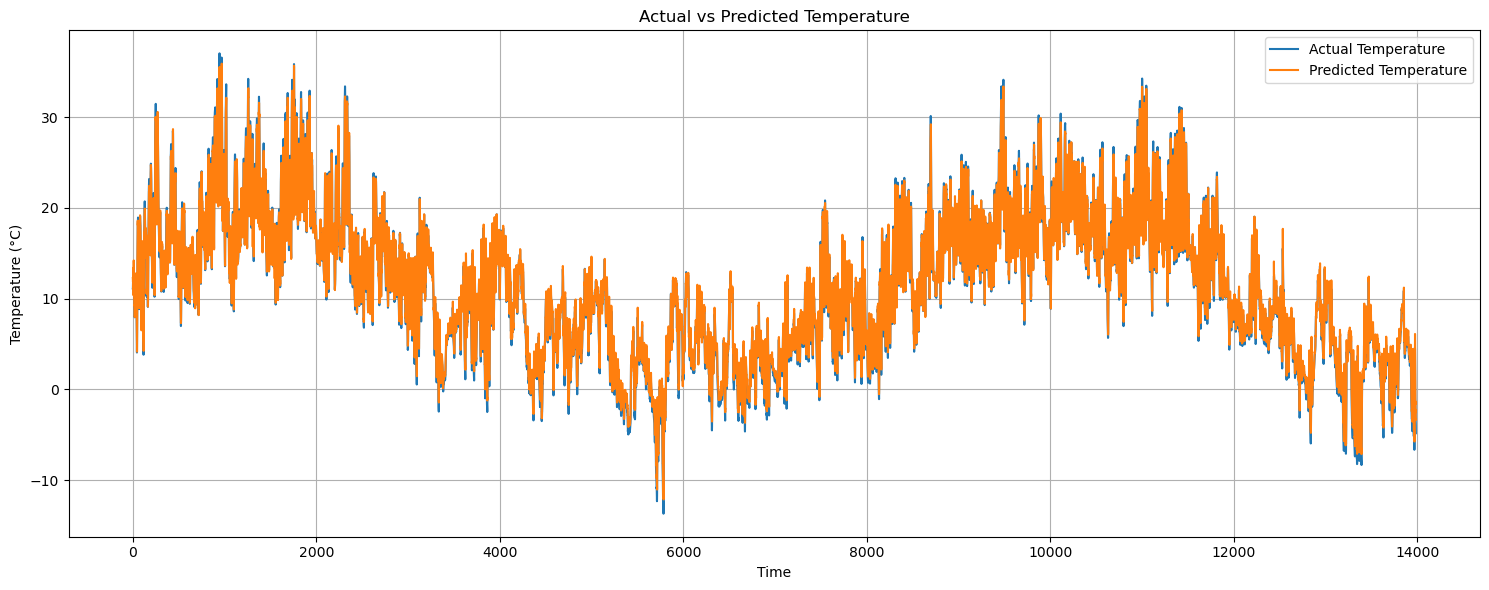

In [21]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual,
    label="Actual Temperature"
)

plt.plot(
    predictions,
    label="Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 20. Visualize a Smaller Test Window

Since the complete test dataset contains thousands of observations,
a smaller section is plotted for easier visual interpretation.

The first 500 test observations are displayed.

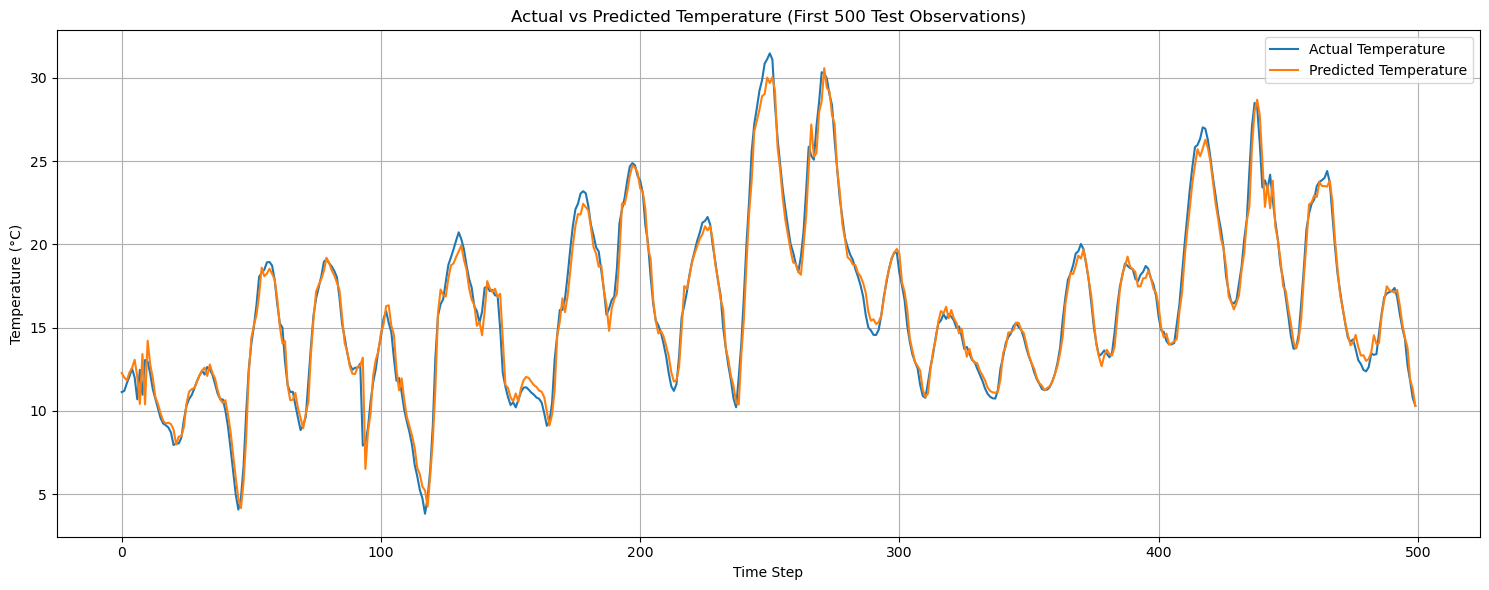

In [22]:
# Number of observations to visualize
PLOT_SIZE = 500

plt.figure(figsize=(15, 6))

plt.plot(
    actual[:PLOT_SIZE],
    label="Actual Temperature"
)

plt.plot(
    predictions[:PLOT_SIZE],
    label="Predicted Temperature"
)

plt.title(
    "Actual vs Predicted Temperature "
    "(First 500 Test Observations)"
)

plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 21. Residual Analysis

Residuals represent the difference between the actual and predicted
temperature values.

Analyzing residuals helps determine whether the model has systematic
prediction errors.

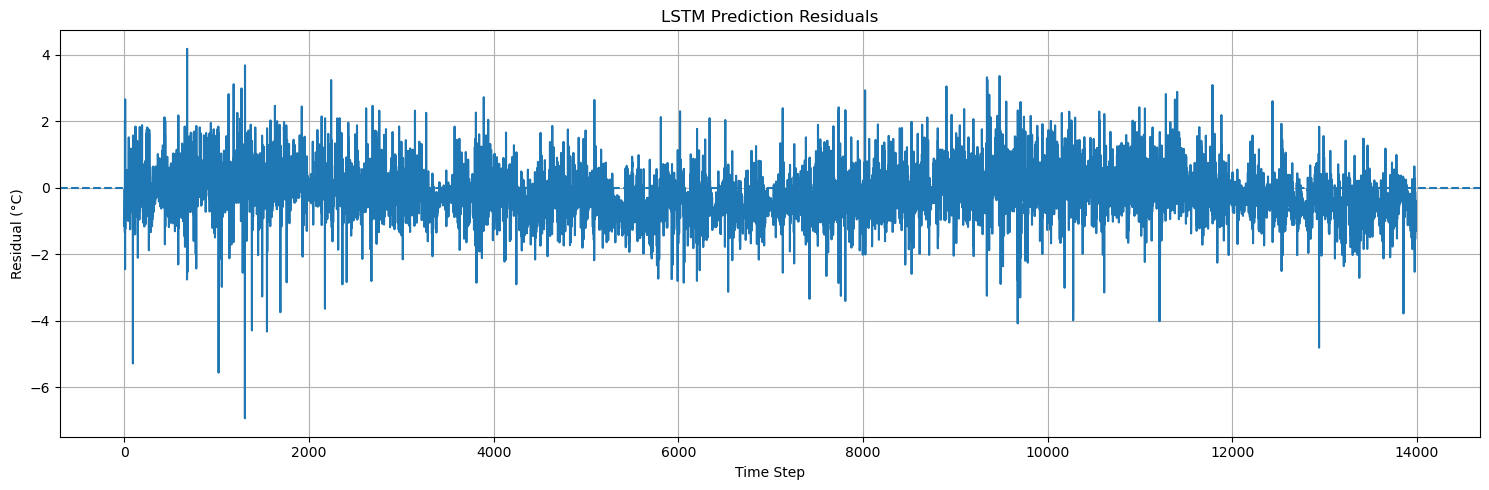

In [23]:
# Calculate residuals
residuals = (
    actual.flatten() -
    predictions.flatten()
)

plt.figure(figsize=(15, 5))

plt.plot(residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("LSTM Prediction Residuals")
plt.xlabel("Time Step")
plt.ylabel("Residual (°C)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 22. Future Temperature Forecasting

The trained LSTM model can also be used to forecast future
temperature values.

A recursive forecasting strategy is used:

1. Take the most recent 24 observations.
2. Predict the next temperature.
3. Add the prediction to the sequence.
4. Remove the oldest observation.
5. Predict the next value.
6. Repeat for the required forecasting horizon.

In [24]:
# Number of future hours to forecast
FUTURE_STEPS = 24

# Use the most recent observations
full_scaled = scaler.transform(data)

current_sequence = full_scaled[-SEQUENCE_LENGTH:].copy()

future_predictions_scaled = []

for _ in range(FUTURE_STEPS):

    # Reshape for LSTM input
    input_sequence = current_sequence.reshape(
        1,
        SEQUENCE_LENGTH,
        1
    )

    # Predict the next temperature
    next_prediction = model.predict(
        input_sequence,
        verbose=0
    )[0, 0]

    # Store prediction
    future_predictions_scaled.append(
        next_prediction
    )

    # Update sequence
    current_sequence = np.concatenate(
        [
            current_sequence[1:],
            np.array([[next_prediction]])
        ],
        axis=0
    )

# Convert predictions back to Celsius
future_predictions = scaler.inverse_transform(
    np.array(
        future_predictions_scaled
    ).reshape(-1, 1)
)

print("Future temperature forecast:")
print(future_predictions.flatten())

Future temperature forecast:
[-4.633096  -3.9027712 -2.6858585 -1.0500461  0.8020537  2.6629283
  4.3555675  5.7647643  6.8391404  7.57492    7.9957705  8.138103
  8.043001   7.7545714  7.3203845  6.7929263  6.2276917  5.67931
  5.199746   4.835097   4.6236033  4.591853   4.752808   5.103254 ]


## 23. Plot Future Temperature Forecast

The following visualization shows the most recent historical
temperature values together with the temperature forecast for the
next 24 hours.

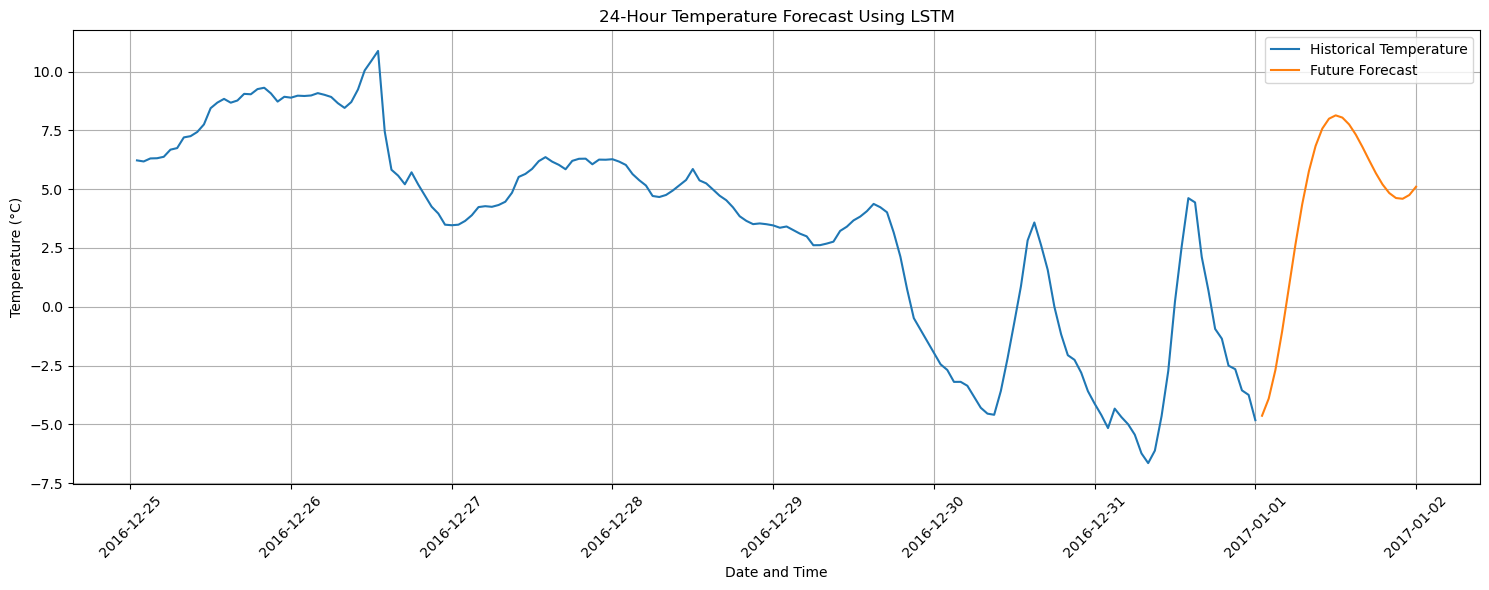

In [25]:
# Number of historical points to display
HISTORICAL_POINTS = 168  # Last 7 days

# Historical timestamps
historical_dates = hourly_temperature.index[-HISTORICAL_POINTS:]

# Future timestamps
last_timestamp = hourly_temperature.index[-1]

future_dates = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=FUTURE_STEPS,
    freq="h"
)

# Historical values
historical_values = hourly_temperature.values[
    -HISTORICAL_POINTS:
]

plt.figure(figsize=(15, 6))

# Historical temperature
plt.plot(
    historical_dates,
    historical_values,
    label="Historical Temperature"
)

# Future forecast
plt.plot(
    future_dates,
    future_predictions.flatten(),
    label="Future Forecast"
)

plt.title("24-Hour Temperature Forecast Using LSTM")
plt.xlabel("Date and Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 24. Future Forecast Table

The predicted temperature values for the next 24 hours are presented
in tabular form for easier interpretation.

In [26]:
# Create future forecast DataFrame
forecast_df = pd.DataFrame({
    "Date Time": future_dates,
    "Predicted Temperature (°C)": future_predictions.flatten()
})

forecast_df

,Date Time,Predicted Temperature (°C)
0,2017-01-01 01:00:00,-4.633096
1,2017-01-01 02:00:00,-3.902771
2,2017-01-01 03:00:00,-2.685858
3,2017-01-01 04:00:00,-1.050046
4,2017-01-01 05:00:00,0.802054
5,2017-01-01 06:00:00,2.662928
6,2017-01-01 07:00:00,4.355567
7,2017-01-01 08:00:00,5.764764
8,2017-01-01 09:00:00,6.839140
9,2017-01-01 10:00:00,7.574920


# 25. Conclusion

In this assignment, an LSTM-based deep learning model was developed
for weather time-series forecasting using the Jena Climate dataset.

The original 10-minute interval observations were converted to
hourly temperature values to make the forecasting problem
computationally efficient.

The data was then:

- Converted into chronological datetime format
- Resampled to hourly frequency
- Split into training and testing sets
- Normalized using Min-Max scaling
- Converted into sequential samples using a sliding window

An LSTM neural network consisting of two LSTM layers and dropout
regularization was trained to predict the next hour's temperature.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Finally, the trained model was used to generate a 24-hour future
temperature forecast.

### Key Learning Outcomes

- Understanding time-series forecasting
- Preparing sequential data for deep learning
- Understanding LSTM input dimensions
- Building an LSTM network using TensorFlow/Keras
- Applying normalization to time-series data
- Evaluating regression-based forecasting models
- Generating recursive future predictions
- Visualizing actual, predicted, and future values

### Final Result

The experiment demonstrates that LSTM networks can learn temporal
dependencies from historical weather observations and use these
patterns to forecast future temperature values.